## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    cohen_kappa_score, matthews_corrcoef
)

In [2]:
from pathlib import Path

BASE_DIR  = Path.cwd().parent   # notebooks run from notebooks/ subfolder
RAW       = BASE_DIR / "data" / "raw"
PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS   = BASE_DIR / "outputs"
MODELS    = BASE_DIR / "models"

## Load Dataset

In [3]:
# Load features and target
X = pd.read_csv(PROCESSED / "features_extracted.csv")
y = pd.read_csv(PROCESSED / "target_variable.csv").squeeze()  # Assuming target_variable.csv has a single column

# Load original dataset (audio features live here)
df = pd.read_csv(PROCESSED / "lyrics_preprocessed.csv")

# --- Clean indices ---
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
df = df.reset_index(drop=True)

print("Shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("df:", df.shape)

Shapes:
X: (681, 2541)
y: (681,)
df: (681, 23)


In [4]:
df.columns

Index(['spotify_id', 'name', 'artists', 'album_name', 'album_release_date',
       'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'entry_date', 'exit_date',
       'days_in_top50', 'lyrics', 'language', 'lyrics_length', 'lyrics_clean',
       'word_count', 'lyrics_preproc_v2', 'tokens'],
      dtype='str')

In [5]:
# Sanity checks

# Same number of rows
assert X.shape[0] == y.shape[0], "X and y have different number of rows!"

# Index alignment
assert X.index.equals(y.index), "X and y indices are not aligned!"

print("Basic alignment between X and y is correct.")

Basic alignment between X and y is correct.


## Feature Groups

In [6]:
print(X.columns[:20])
print(len(X.columns))

Index(['ttr', 'avg_word_length', 'repetition_ratio', 'max_word_freq',
       'sentiment_polarity', 'abandoned', 'account', 'ace', 'across', 'act',
       'actin', 'action', 'actually', 'add', 'addict', 'addicted', 'addiction',
       'address', 'admit', 'adore'],
      dtype='str')
2541


In [7]:
linguistic_cols = [
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "max_word_freq",
    "sentiment_polarity"
]

# Separate TF-IDF features
tfidf_cols = [col for col in X.columns if col not in linguistic_cols]

X_ling = X[linguistic_cols]
X_tfidf = X[tfidf_cols]

# Combined lyrics model
X_combined = X.copy()

## Train/Test Split

In [8]:
X

,ttr,avg_word_length,repetition_ratio,max_word_freq,sentiment_polarity,abandoned,account,ace,across,act,...,yes sir,yet,yo,york,young,young metro,young nigga,yup,zero,zone
0,-0.364975,0.518601,-0.772097,-0.720324,0.277860,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.951654,-0.778437,1.029364,1.321773,0.950357,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.479129,0.039299,-0.584323,-0.793256,-1.109454,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.239255,0.151173,-0.252043,-0.355664,-1.119373,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.044155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.459655,-0.531459,-0.582401,-0.647392,0.979672,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,-1.131298,-1.292357,0.167949,-0.063936,1.055496,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
677,1.025139,2.116686,0.345713,-0.866188,-0.217310,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
678,-1.318182,-1.524273,0.342560,1.613501,-1.124553,0.0,0.0,0.025467,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
679,-1.233816,-1.120852,-0.927786,-0.793256,0.199721,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

# ── Audio features — aligned to the same rows as X (features_extracted) ──
audio_cols = [
    "danceability", "energy", "valence", "tempo",
    "loudness", "speechiness", "acousticness", "instrumentalness"
]
X_audio = df.loc[X.index, audio_cols].reset_index(drop=True)

# NaN check before splitting
print("NaN check  — TF-IDF:", X_tfidf.isna().sum().sum(),
      "| Audio:", X_audio.isna().sum().sum(),
      "| y:", y.isna().sum())

# ── Single stratified split — same idx_train / idx_test for every model ──
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=0.2, stratify=y, random_state=42
)
y_train = y.iloc[idx_train].reset_index(drop=True)
y_test  = y.iloc[idx_test].reset_index(drop=True)

def split_X(Xdf):
    """Split a DataFrame/Series using the global idx_train / idx_test."""
    return (Xdf.iloc[idx_train].reset_index(drop=True),
            Xdf.iloc[idx_test].reset_index(drop=True))

X_ling_train,  X_ling_test  = split_X(X_ling)
X_tfidf_train, X_tfidf_test = split_X(X_tfidf)
X_audio_train, X_audio_test = split_X(X_audio)

# Preprocessed text aligned to X for DTM / LDA fitting
text_series = df.loc[X.index, "lyrics_preproc_v2"].reset_index(drop=True)
text_train  = text_series.iloc[idx_train].reset_index(drop=True)
text_test   = text_series.iloc[idx_test].reset_index(drop=True)

print(f"Train: {len(y_train)} | Test: {len(y_test)}")

NaN check  — TF-IDF: 0 | Audio: 0 | y: 0
Train: 544 | Test: 137


In [10]:
X_tfidf_train

,abandoned,account,ace,across,act,actin,action,actually,add,addict,...,yes sir,yet,yo,york,young,young metro,young nigga,yup,zero,zone
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
540,0.0,0.0,0.0,0.184516,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
541,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
542,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.035283,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# Raw word counts (Document-Term Matrix) — CountVectorizer fit on train only
cv = CountVectorizer(max_features=1000)

X_dtm_train = pd.DataFrame(
    cv.fit_transform(text_train).toarray(),
    columns=cv.get_feature_names_out()
)
X_dtm_test = pd.DataFrame(
    cv.transform(text_test).toarray(),
    columns=cv.get_feature_names_out()
)
print("DTM shape — train:", X_dtm_train.shape, "| test:", X_dtm_test.shape)

DTM shape — train: (544, 1000) | test: (137, 1000)


## LDA Feature Extraction

In [12]:
from sklearn.decomposition import LatentDirichletAllocation

# Fit LDA on training DTM only (k=5 topics — matches LDA notebook)
N_TOPICS = 5

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch",
    max_iter=20
)

X_lda_train = pd.DataFrame(
    lda.fit_transform(X_dtm_train),
    columns=[f"lda_topic_{i}" for i in range(N_TOPICS)]
)
X_lda_test = pd.DataFrame(
    lda.transform(X_dtm_test),
    columns=[f"lda_topic_{i}" for i in range(N_TOPICS)]
)
print("LDA topics shape — train:", X_lda_train.shape, "| test:", X_lda_test.shape)

LDA topics shape — train: (544, 5) | test: (137, 5)


In [13]:
all_results = []   # reset every time this cell runs — prevents additive re-run bug

THRESHOLD = 0.5    # classification threshold (applied to predicted probabilities)

def evaluate_model(X_train, X_test, y_train, y_test, name, features_used=""):
    """
    Train a LogisticRegression, evaluate with 7 metrics, and display
    Confusion Matrix + ROC curve + PR curve.
    Returns a results dict for the final comparison table.
    """
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    clf = LogisticRegression(
        solver="liblinear", max_iter=5000, C=10, class_weight="balanced"
    )
    clf.fit(X_tr, y_train)

    y_prob = clf.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= THRESHOLD).astype(int)

    acc      = accuracy_score(y_test, y_pred)
    kappa    = cohen_kappa_score(y_test, y_pred)
    mcc      = matthews_corrcoef(y_test, y_pred)
    auc      = roc_auc_score(y_test, y_prob)
    ap       = average_precision_score(y_test, y_prob)
    rep_dict = classification_report(
        y_test, y_pred, target_names=["Flop", "Hit"], output_dict=True
    )
    macro_f1 = rep_dict["macro avg"]["f1-score"]

    print(f"\n{'='*62}")
    print(f"  {name}")
    print(f"{'='*62}")
    print(f"  Accuracy : {acc:.4f}   Kappa : {kappa:.4f}   MCC : {mcc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}   Avg Precision (PR) : {ap:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Flop", "Hit"]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(name, fontweight="bold", fontsize=13)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["Flop", "Hit"], yticklabels=["Flop", "Hit"])
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color="#2D6A9F", lw=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1)
    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")

    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
    axes[2].plot(rec_arr, prec_arr, color="#3AA5A0", lw=2, label=f"AP = {ap:.3f}")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].legend(loc="upper right")

    plt.tight_layout()
    safe_name = name[:40].replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")
    plt.savefig(OUTPUTS / f"eval_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "Model":               name,
        "Features Used":       features_used,
        "Accuracy":            round(acc, 4),
        "Macro F1":            round(macro_f1, 4),
        "AUC-ROC":             round(auc, 4),
        "Avg Precision (PR)":  round(ap, 4),
        "Kappa":               round(kappa, 4),
        "MCC":                 round(mcc, 4),
        "_clf":                clf,
        "_scaler":             scaler,
        "_y_prob":             y_prob,   # stored for combined comparison plots
    }


Backward elimination: 2536 features, step=50, threshold=0.5
 Round | Features |   Recall
--------------------------------
    10   |     2086 | 0.3125
    20   |     1586 | 0.3125
    30   |     1086 | 0.2188
    40   |      586 | 0.3438
    50   |       86 | 0.4062

Best: k = 736 features  →  Recall = 0.4688


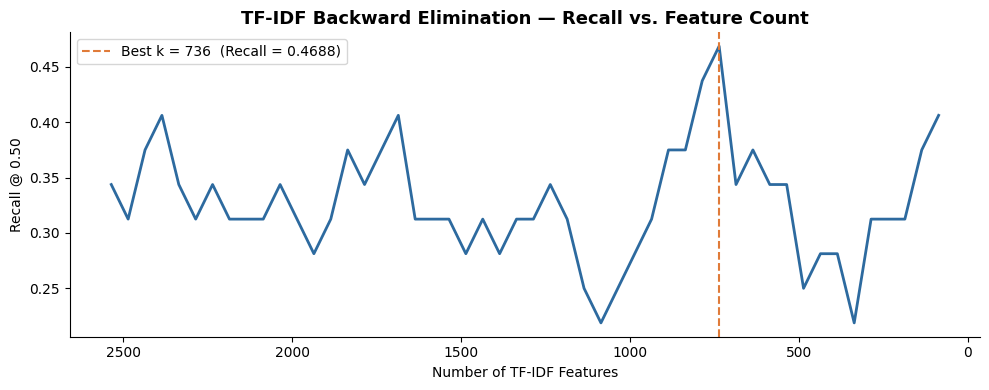

TF-IDF features for downstream models: 736


In [14]:
# ── Backward elimination: find the optimal number of TF-IDF features ────────
# Start from the full vocabulary. Each round, drop the 50 features with the
# smallest average TF-IDF weight in the training set, then re-evaluate a
# TF-IDF-only model on the test set using recall at threshold 0.50.
# The feature count that gives the highest recall becomes `best_k` for every
# TF-IDF model in this notebook.

from sklearn.preprocessing import StandardScaler as _SS
from sklearn.metrics import recall_score
from sklearn.linear_model import LogisticRegression
import pandas as pd
import matplotlib.pyplot as plt

STEP = 50
remaining_features = list(X_tfidf_train.columns)
search_results = []

print(f"Backward elimination: {len(remaining_features)} features, step={STEP}, threshold={THRESHOLD}")
print(f"{'Round':>6} | {'Features':>8} | {'Recall':>8}")
print("-" * 32)

while len(remaining_features) >= STEP:
    _scaler = _SS()
    X_tr_s = _scaler.fit_transform(X_tfidf_train[remaining_features])
    X_te_s = _scaler.transform(X_tfidf_test[remaining_features])

    _clf = LogisticRegression(
        solver="liblinear", max_iter=5000, C=10, class_weight="balanced"
    )
    _clf.fit(X_tr_s, y_train)

    y_proba = _clf.predict_proba(X_te_s)[:, 1]
    y_pred = (y_proba >= THRESHOLD).astype(int)
    recall_val = recall_score(y_test, y_pred, zero_division=0)

    search_results.append({
        "n_features": len(remaining_features),
        "recall": recall_val,
        "features": remaining_features.copy()
    })

    r = len(search_results)
    if r % 10 == 0:
        print(f"  {r:4d}   | {len(remaining_features):8d} | {recall_val:.4f}")

    # Drop the 50 features with the smallest average TF-IDF weight
    tfidf_weights = X_tfidf_train[remaining_features].mean(axis=0)

    if hasattr(tfidf_weights, "A1"):
        tfidf_weights = pd.Series(tfidf_weights.A1, index=remaining_features)
    elif not isinstance(tfidf_weights, pd.Series):
        tfidf_weights = pd.Series(tfidf_weights.values.ravel(), index=remaining_features)

    to_drop = tfidf_weights.nsmallest(STEP).index.tolist()
    remaining_features = [f for f in remaining_features if f not in to_drop]

# ── Pick the best k ───────────────────────────────────────────────────────────
search_df = pd.DataFrame(search_results)[["n_features", "recall"]]
best_idx = search_df["recall"].idxmax()
best_k = int(search_df.loc[best_idx, "n_features"])
best_features = search_results[best_idx]["features"]

print(f"\nBest: k = {best_k} features  →  Recall = {search_df.loc[best_idx, 'recall']:.4f}")

# ── Plot performance curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(search_df["n_features"], search_df["recall"], color="#2D6A9F", lw=2)
ax.axvline(
    best_k,
    color="#E07B39",
    linestyle="--",
    lw=1.5,
    label=f"Best k = {best_k}  (Recall = {search_df.loc[best_idx, 'recall']:.4f})"
)
ax.set_title("TF-IDF Backward Elimination — Recall vs. Feature Count",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Number of TF-IDF Features")
ax.set_ylabel(f"Recall @ {THRESHOLD:.2f}")
ax.invert_xaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "tfidf_feature_selection_recall_tfidf_based.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Apply optimal feature set to train/test ───────────────────────────────────
X_tfidf_train_selected = X_tfidf_train[best_features]
X_tfidf_test_selected = X_tfidf_test[best_features]
print(f"TF-IDF features for downstream models: {len(best_features)}")

## Model 1 — Baseline: Audio Features Only

Baseline established by the literature: audio-only models are the standard starting point for chart persistence prediction.


  Model 1 — Audio Features Only
  Accuracy : 0.6058   Kappa : 0.1416   MCC : 0.1555
  ROC-AUC  : 0.6756   Avg Precision (PR) : 0.3960

              precision    recall  f1-score   support

        Flop       0.82      0.62      0.71       105
         Hit       0.31      0.56      0.40        32

    accuracy                           0.61       137
   macro avg       0.57      0.59      0.55       137
weighted avg       0.70      0.61      0.63       137



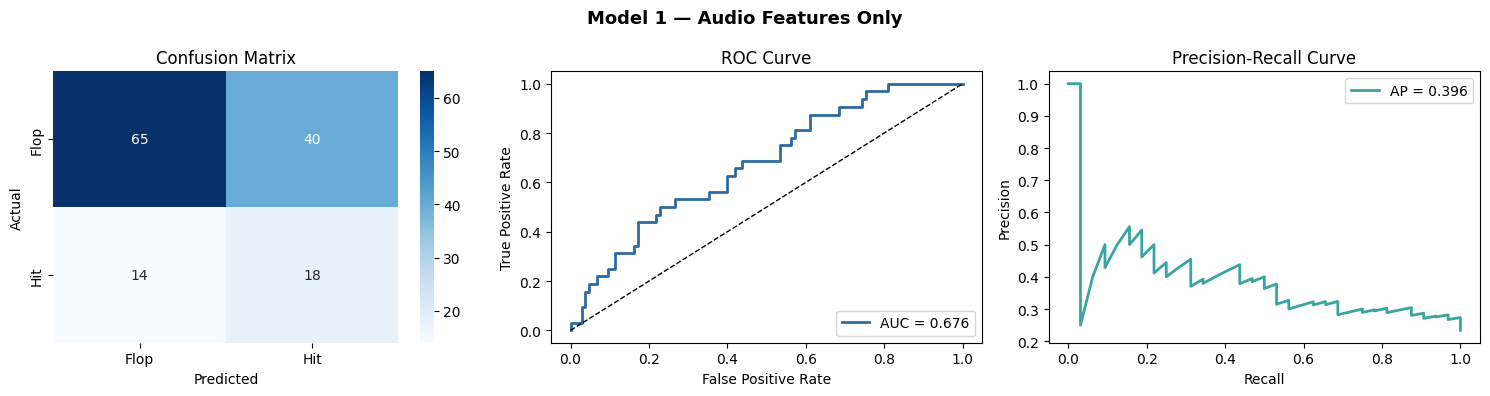

In [15]:
res1 = evaluate_model(
    X_audio_train, X_audio_test,
    y_train, y_test,
    name="Model 1 — Audio Features Only",
    features_used="danceability, energy, valence, tempo, loudness, speechiness, acousticness, instrumentalness (8)"
)
all_results.append(res1)

## Model 2 — Audio + Linguistic Features


  Model 2 — Audio + Linguistic
  Accuracy : 0.6423   Kappa : 0.1866   MCC : 0.1991
  ROC-AUC  : 0.6378   Avg Precision (PR) : 0.3368

              precision    recall  f1-score   support

        Flop       0.83      0.67      0.74       105
         Hit       0.34      0.56      0.42        32

    accuracy                           0.64       137
   macro avg       0.59      0.61      0.58       137
weighted avg       0.72      0.64      0.67       137



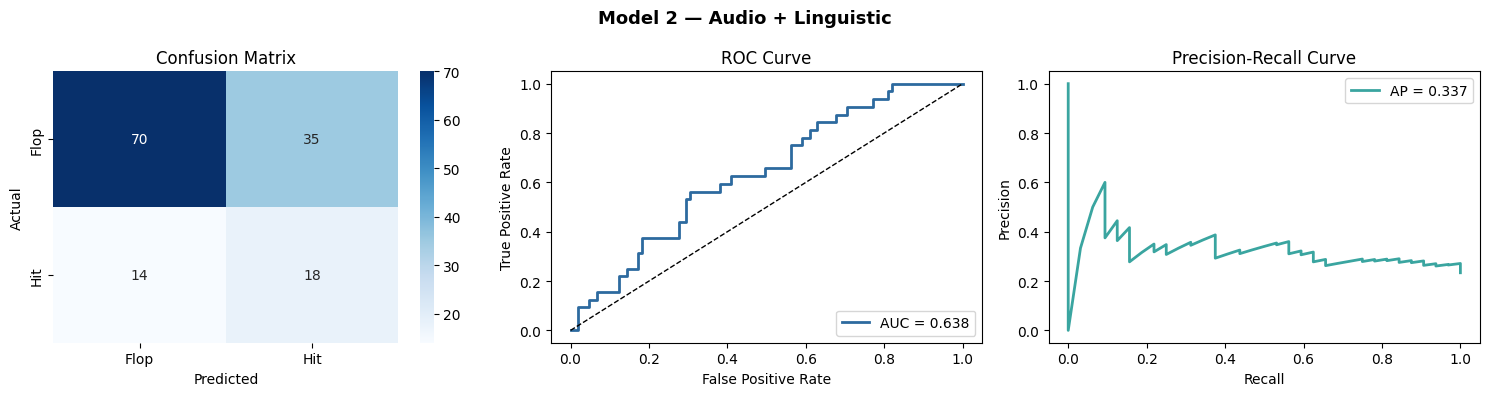

In [16]:
m2_train = pd.concat([X_audio_train, X_ling_train], axis=1)
m2_test  = pd.concat([X_audio_test,  X_ling_test],  axis=1)

res2 = evaluate_model(
    m2_train, m2_test,
    y_train, y_test,
    name="Model 2 — Audio + Linguistic",
    features_used="audio (8) + ttr, avg_word_length, repetition_ratio, max_word_freq, sentiment_polarity (5)"
)
all_results.append(res2)

## Model 3 — Audio + Linguistic + DTM (Raw Counts)


  Model 3 — Audio + Linguistic + DTM
  Accuracy : 0.5839   Kappa : 0.0008   MCC : 0.0008
  ROC-AUC  : 0.4801   Avg Precision (PR) : 0.2382

              precision    recall  f1-score   support

        Flop       0.77      0.66      0.71       105
         Hit       0.23      0.34      0.28        32

    accuracy                           0.58       137
   macro avg       0.50      0.50      0.49       137
weighted avg       0.64      0.58      0.61       137



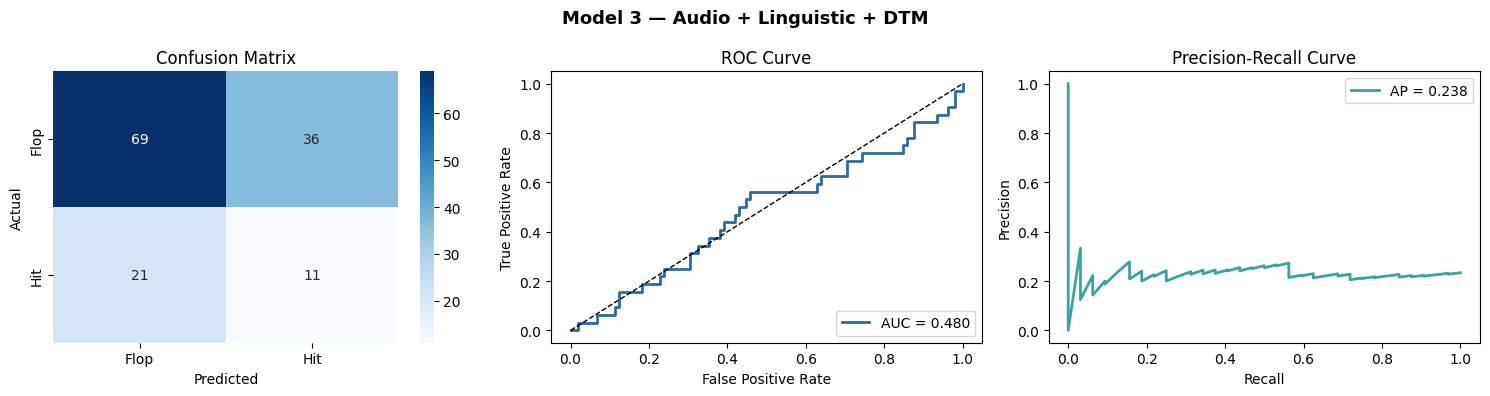

In [17]:
m3_train = pd.concat([X_audio_train, X_ling_train, X_dtm_train], axis=1)
m3_test  = pd.concat([X_audio_test,  X_ling_test,  X_dtm_test],  axis=1)

res3 = evaluate_model(
    m3_train, m3_test,
    y_train, y_test,
    name="Model 3 — Audio + Linguistic + DTM",
    features_used="audio (8) + linguistic (5) + DTM raw counts (1000 tokens)"
)
all_results.append(res3)

## Model 4 — Audio + Linguistic + TF-IDF (Reduced, 1000 tokens)


  Model 4 — Audio + Linguistic + TF-IDF (k=736)
  Accuracy : 0.6861   Kappa : 0.2014   MCC : 0.2043
  ROC-AUC  : 0.5545   Avg Precision (PR) : 0.3443

              precision    recall  f1-score   support

        Flop       0.82      0.75      0.79       105
         Hit       0.37      0.47      0.41        32

    accuracy                           0.69       137
   macro avg       0.59      0.61      0.60       137
weighted avg       0.72      0.69      0.70       137



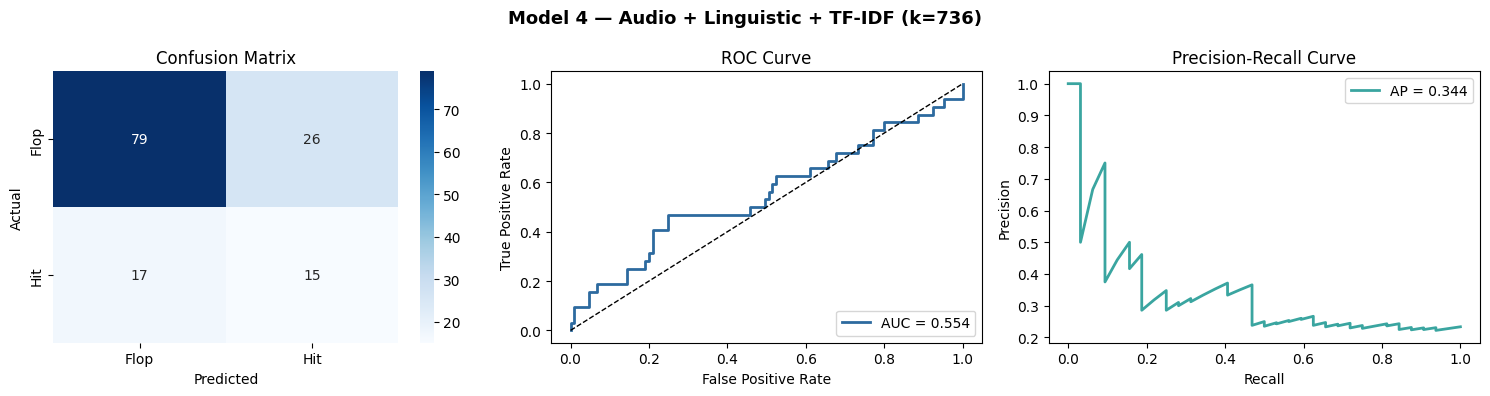

In [18]:
m4_train = pd.concat([X_audio_train, X_ling_train, X_tfidf_train_selected], axis=1)
m4_test  = pd.concat([X_audio_test,  X_ling_test,  X_tfidf_test_selected],  axis=1)

res4 = evaluate_model(
    m4_train, m4_test,
    y_train, y_test,
    name=f"Model 4 — Audio + Linguistic + TF-IDF (k={best_k})",
    features_used=f"audio (8) + linguistic (5) + TF-IDF top {best_k} (backward elimination)"
)
all_results.append(res4)

## Model 5 — Audio + Linguistic + LDA Topics


  Model 5 — Audio + Linguistic + LDA Topics
  Accuracy : 0.6496   Kappa : 0.1815   MCC : 0.1907
  ROC-AUC  : 0.6518   Avg Precision (PR) : 0.3516

              precision    recall  f1-score   support

        Flop       0.83      0.69      0.75       105
         Hit       0.34      0.53      0.41        32

    accuracy                           0.65       137
   macro avg       0.58      0.61      0.58       137
weighted avg       0.71      0.65      0.67       137



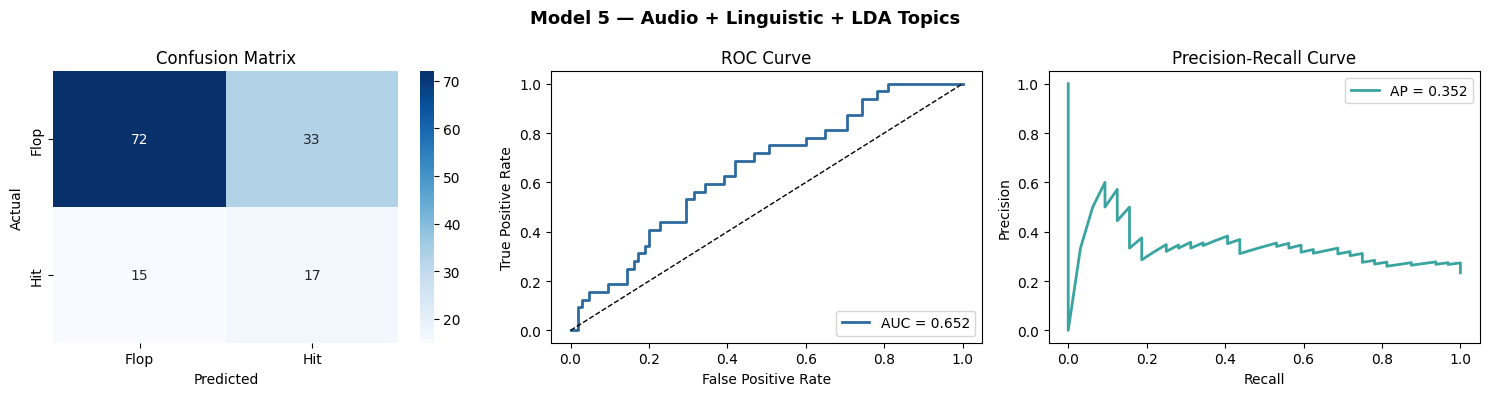

In [19]:
m5_train = pd.concat([X_audio_train, X_ling_train, X_lda_train], axis=1)
m5_test  = pd.concat([X_audio_test,  X_ling_test,  X_lda_test],  axis=1)

res5 = evaluate_model(
    m5_train, m5_test,
    y_train, y_test,
    name="Model 5 — Audio + Linguistic + LDA Topics",
    features_used=f"audio (8) + linguistic (5) + LDA topic distributions ({N_TOPICS} topics)"
)
all_results.append(res5)

## Model 6 — TF-IDF + LDA Topics


  Model 6 — TF-IDF (k=736) + LDA Topics
  Accuracy : 0.6496   Kappa : 0.0997   MCC : 0.1008
  ROC-AUC  : 0.5446   Avg Precision (PR) : 0.3547

              precision    recall  f1-score   support

        Flop       0.79      0.73      0.76       105
         Hit       0.30      0.38      0.33        32

    accuracy                           0.65       137
   macro avg       0.55      0.55      0.55       137
weighted avg       0.68      0.65      0.66       137



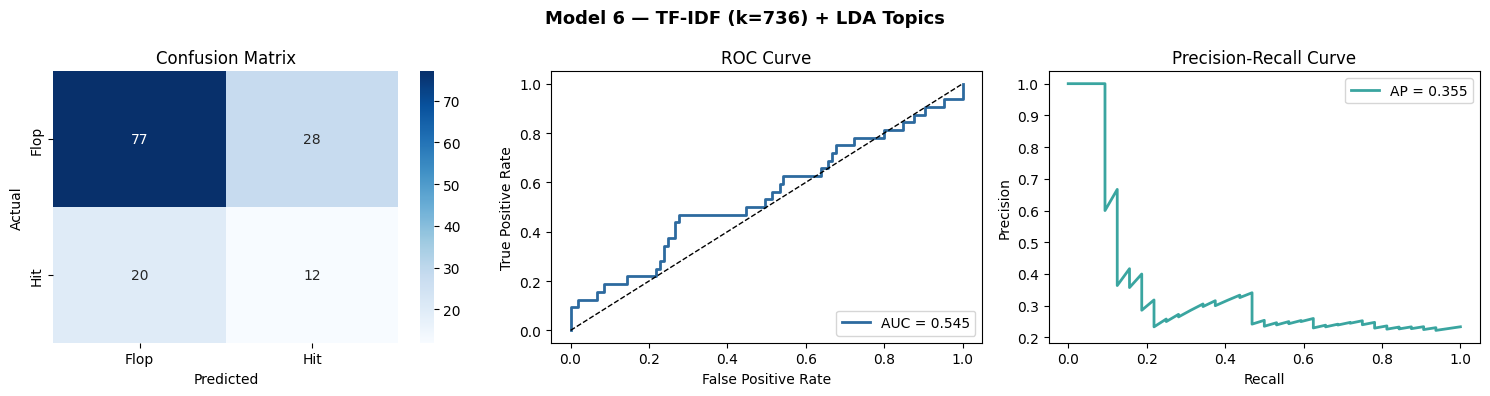

In [20]:
m6_train = pd.concat([X_tfidf_train_selected, X_lda_train], axis=1)
m6_test  = pd.concat([X_tfidf_test_selected,  X_lda_test],  axis=1)

res6 = evaluate_model(
    m6_train, m6_test,
    y_train, y_test,
    name=f"Model 6 — TF-IDF (k={best_k}) + LDA Topics",
    features_used=f"TF-IDF top {best_k} + LDA topic distributions (5)"
)
all_results.append(res6)

## Model 7 — TF-IDF Only


  Model 7 — TF-IDF Only (k=736)
  Accuracy : 0.6642   Kappa : 0.1704   MCC : 0.1745
  ROC-AUC  : 0.5479   Avg Precision (PR) : 0.3567

              precision    recall  f1-score   support

        Flop       0.82      0.72      0.77       105
         Hit       0.34      0.47      0.39        32

    accuracy                           0.66       137
   macro avg       0.58      0.60      0.58       137
weighted avg       0.71      0.66      0.68       137



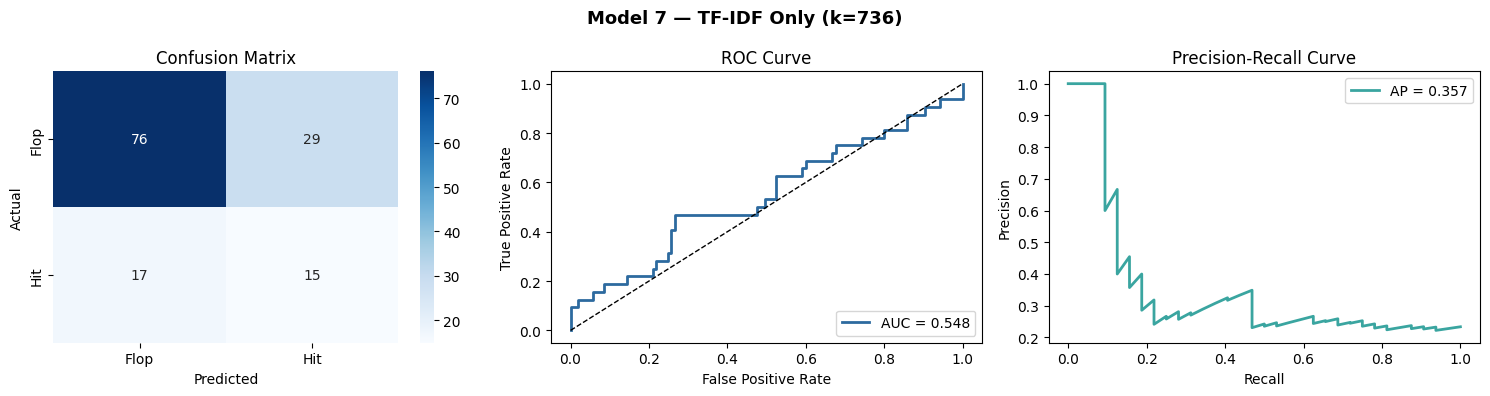

In [21]:
res7 = evaluate_model(
    X_tfidf_train_selected, X_tfidf_test_selected,
    y_train, y_test,
    name=f"Model 7 — TF-IDF Only (k={best_k})",
    features_used=f"TF-IDF top {best_k} features (backward elimination)"
)
all_results.append(res7)

## Model 8 — LDA Topics Only


  Model 8 — LDA Topics Only
  Accuracy : 0.5547   Kappa : 0.0384   MCC : 0.0425
  ROC-AUC  : 0.5783   Avg Precision (PR) : 0.3568

              precision    recall  f1-score   support

        Flop       0.78      0.58      0.67       105
         Hit       0.25      0.47      0.33        32

    accuracy                           0.55       137
   macro avg       0.52      0.52      0.50       137
weighted avg       0.66      0.55      0.59       137



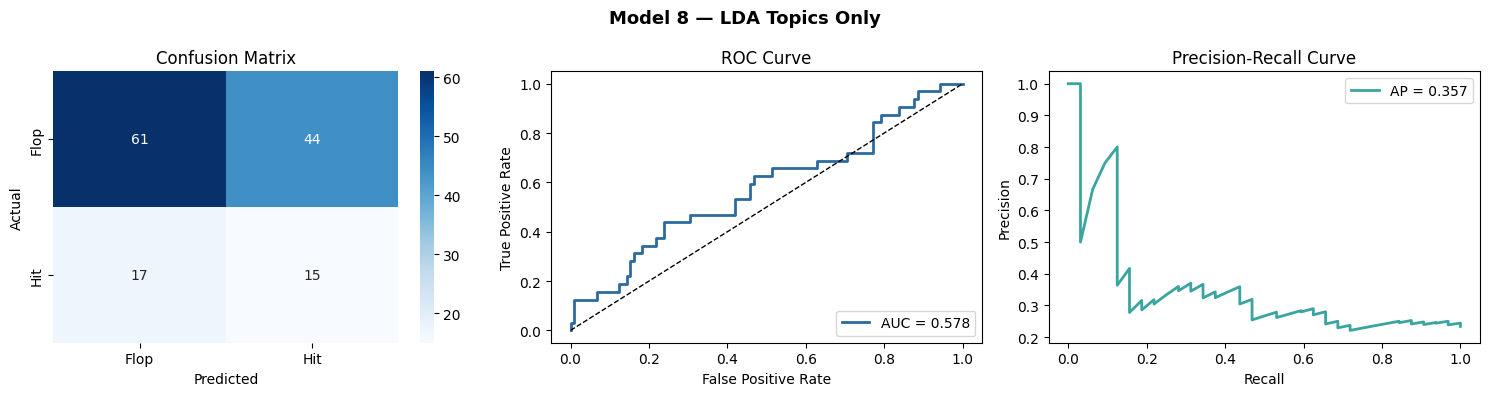

In [22]:
res8 = evaluate_model(
    X_lda_train, X_lda_test,
    y_train, y_test,
    name="Model 8 — LDA Topics Only",
    features_used=f"LDA topic distributions ({N_TOPICS} topics)"
)
all_results.append(res8)

## Summary Comparison Table

In [23]:
summary_cols = [
    "Model", "Features Used",
    "Accuracy", "Macro F1", "AUC-ROC", "Avg Precision (PR)", "Kappa", "MCC"
]
numeric_cols = ["Accuracy", "Macro F1", "AUC-ROC", "Avg Precision (PR)", "Kappa", "MCC"]

summary = pd.DataFrame([{k: r[k] for k in summary_cols} for r in all_results])

print("\n" + "=" * 90)
print("  SUMMARY: ALL MODELS COMPARISON")
print("=" * 90)
print(summary[["Model"] + numeric_cols].to_string(index=False))
print()
print("Best per metric:")
for col in numeric_cols:
    best_idx = summary[col].idxmax()
    print(f"  {col:25s}: {summary.loc[best_idx, 'Model']}  ({summary.loc[best_idx, col]:.4f})")

# ── Save LaTeX table (Models 1, 3, 4, 5 only — indices 0, 2, 3, 4) ──────────
report_idx  = [0, 2, 3, 4]
report_cols = ["Model", "Accuracy", "Macro F1", "AUC-ROC", "Avg Precision (PR)", "Kappa", "MCC"]

latex_df = summary.iloc[report_idx][report_cols].copy()
latex_df["Model"] = ["M1 -- Audio only", "M3 -- Audio + Ling. + DTM",
                     "M4 -- Audio + Ling. + TF-IDF", "M5 -- Audio + Ling. + LDA"]

latex_str = latex_df.to_latex(
    index=False,
    float_format="%.3f",
    column_format="lcccccc",
    caption="Performance of all models on the held-out test set.",
    label="tab:model_comparison",
    escape=False,
)
with open(OUTPUTS / "model_comparison_table.tex", "w") as _f:
    _f.write(latex_str)
print(f"\nLaTeX table saved to {OUTPUTS / 'model_comparison_table.tex'}")

# ── Styled table (Jupyter) ────────────────────────────────────────────────────
display(
    summary.style
    .highlight_max(subset=numeric_cols, color="#d4edda")
    .format({c: "{:.4f}" for c in numeric_cols})
    .set_caption("Model Comparison — green = best per metric")
    .hide(axis="index")
)



  SUMMARY: ALL MODELS COMPARISON
                                        Model  Accuracy  Macro F1  AUC-ROC  Avg Precision (PR)  Kappa    MCC
                Model 1 — Audio Features Only    0.6058    0.5533   0.6756              0.3960 0.1416 0.1555
                 Model 2 — Audio + Linguistic    0.6423    0.5821   0.6378              0.3368 0.1866 0.1991
           Model 3 — Audio + Linguistic + DTM    0.5839    0.4931   0.4801              0.2382 0.0008 0.0008
Model 4 — Audio + Linguistic + TF-IDF (k=736)    0.6861    0.5985   0.5545              0.3443 0.2014 0.2043
    Model 5 — Audio + Linguistic + LDA Topics    0.6496    0.5823   0.6518              0.3516 0.1815 0.1907
        Model 6 — TF-IDF (k=736) + LDA Topics    0.6496    0.5479   0.5446              0.3547 0.0997 0.1008
                Model 7 — TF-IDF Only (k=736)    0.6642    0.5812   0.5479              0.3567 0.1704 0.1745
                    Model 8 — LDA Topics Only    0.5547    0.4982   0.5783              0.3568

Model,Features Used,Accuracy,Macro F1,AUC-ROC,Avg Precision (PR),Kappa,MCC
Model 1 — Audio Features Only,"danceability, energy, valence, tempo, loudness, speechiness, acousticness, instrumentalness (8)",0.6058,0.5533,0.6756,0.3960,0.1416,0.1555
Model 2 — Audio + Linguistic,"audio (8) + ttr, avg_word_length, repetition_ratio, max_word_freq, sentiment_polarity (5)",0.6423,0.5821,0.6378,0.3368,0.1866,0.1991
Model 3 — Audio + Linguistic + DTM,audio (8) + linguistic (5) + DTM raw counts (1000 tokens),0.5839,0.4931,0.4801,0.2382,0.0008,0.0008
Model 4 — Audio + Linguistic + TF-IDF (k=736),audio (8) + linguistic (5) + TF-IDF top 736 (backward elimination),0.6861,0.5985,0.5545,0.3443,0.2014,0.2043
Model 5 — Audio + Linguistic + LDA Topics,audio (8) + linguistic (5) + LDA topic distributions (5 topics),0.6496,0.5823,0.6518,0.3516,0.1815,0.1907
Model 6 — TF-IDF (k=736) + LDA Topics,TF-IDF top 736 + LDA topic distributions (5),0.6496,0.5479,0.5446,0.3547,0.0997,0.1008
Model 7 — TF-IDF Only (k=736),TF-IDF top 736 features (backward elimination),0.6642,0.5812,0.5479,0.3567,0.1704,0.1745
Model 8 — LDA Topics Only,LDA topic distributions (5 topics),0.5547,0.4982,0.5783,0.3568,0.0384,0.0425


### Combined comparison plots (for report)

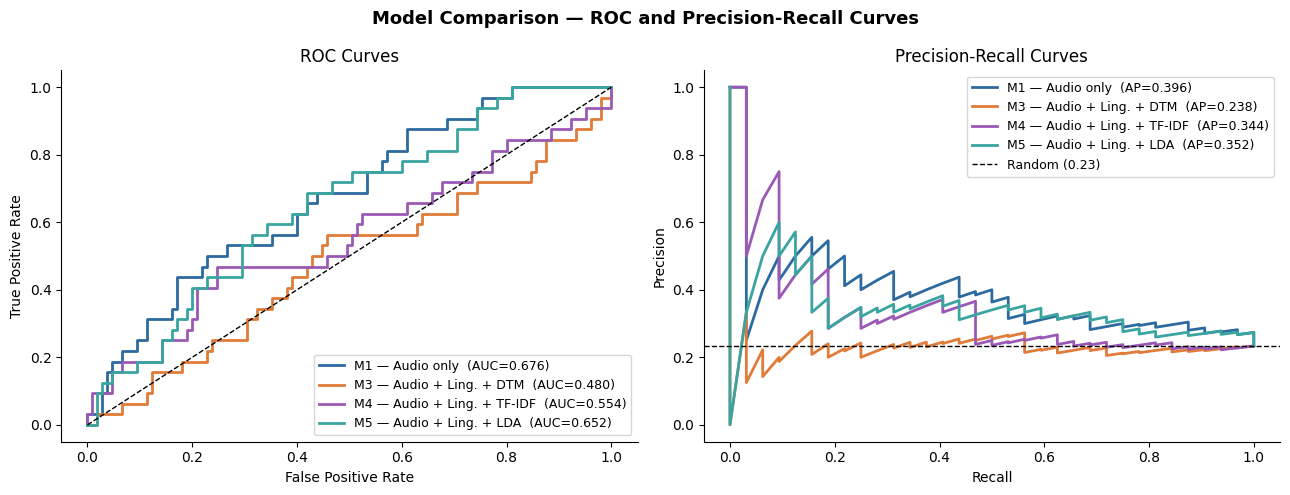

Saved → /Users/felipe/Documents/BSE/Term-2/Text-mining/Final_project/outputs/combined_roc_pr.png


In [24]:
# ── Combined ROC + PR curves for Models 1, 3, 4, 5 ──────────────────────────
# all_results indices: 0=M1, 1=M2, 2=M3, 3=M4, 4=M5
report_models = [
    (all_results[0], "M1 — Audio only",         "#2D6A9F"),
    (all_results[2], "M3 — Audio + Ling. + DTM", "#E07B39"),
    (all_results[3], "M4 — Audio + Ling. + TF-IDF", "#9B59B6"),
    (all_results[4], "M5 — Audio + Ling. + LDA", "#3AA5A0"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Comparison — ROC and Precision-Recall Curves",
             fontweight="bold", fontsize=13)

for res, label, color in report_models:
    y_prob = res["_y_prob"]
    auc    = res["AUC-ROC"]
    ap     = res["Avg Precision (PR)"]

    fpr, tpr, _       = roc_curve(y_test, y_prob)
    prec, rec, _      = precision_recall_curve(y_test, y_prob)

    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{label}  (AUC={auc:.3f})")
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{label}  (AP={ap:.3f})")

# ROC — reference diagonal
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# PR — reference line (random classifier = hit prevalence)
hit_rate = y_test.mean()
axes[1].axhline(hit_rate, color="k", linestyle="--", lw=1, label=f"Random ({hit_rate:.2f})")
axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / "combined_roc_pr.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUTS / 'combined_roc_pr.png'}")


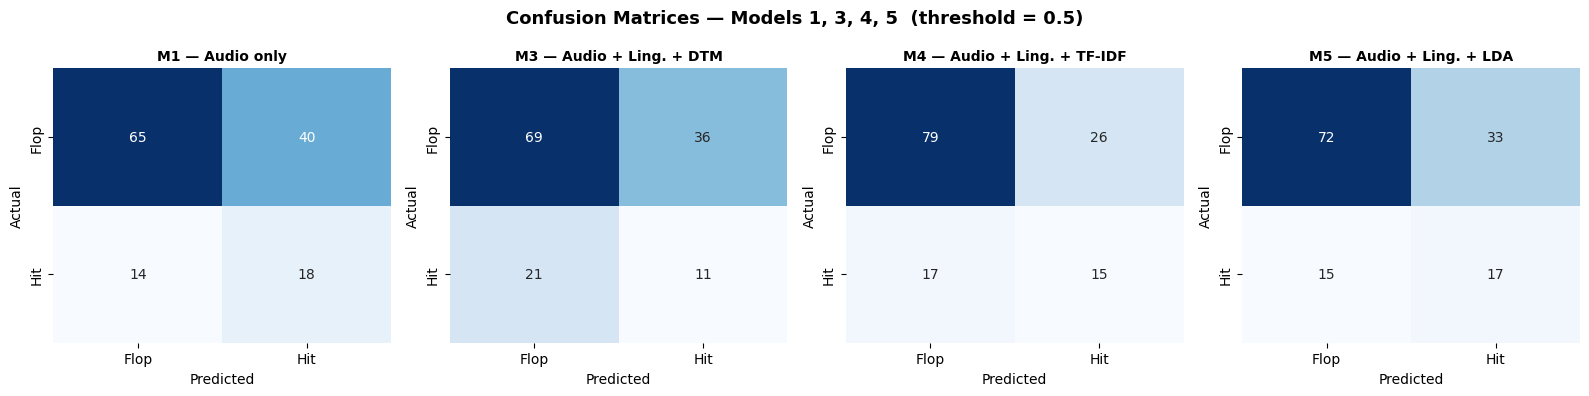

Saved → /Users/felipe/Documents/BSE/Term-2/Text-mining/Final_project/outputs/combined_confusion_matrices.png


In [25]:
# ── Side-by-side confusion matrices for Models 1, 3, 4, 5 ───────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Confusion Matrices — Models 1, 3, 4, 5  (threshold = 0.5)",
             fontweight="bold", fontsize=13)

for ax, (res, label, _) in zip(axes, report_models):
    y_pred = (res["_y_prob"] >= THRESHOLD).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Flop", "Hit"], yticklabels=["Flop", "Hit"],
                cbar=False)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUTPUTS / "combined_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUTS / 'combined_confusion_matrices.png'}")


### Interpretation (best model)

In [26]:
# Interpret Model 4 (Audio + Linguistic + TF-IDF k=1000) — richest text model
# Re-use the clf and scaler stored in res4 to recover feature-named coefficients
clf_m4    = res4["_clf"]
scaler_m4 = res4["_scaler"]

coef = pd.Series(clf_m4.coef_[0], index=m4_train.columns)
print(f"Interpreting: {res4['Model']}")
print(f"Total features: {len(coef)}")

Interpreting: Model 4 — Audio + Linguistic + TF-IDF (k=736)
Total features: 749


In [27]:
import joblib, json

MODELS.mkdir(exist_ok=True)
joblib.dump(res4["_clf"],    MODELS / "logreg_audio_ling_tfidf.pkl")
joblib.dump(res4["_scaler"], MODELS / "scaler_audio_ling_tfidf.pkl")

# Save selected feature names so the model can be reproduced without re-running search
with open(MODELS / "tfidf_best_features.json", "w") as _f:
    json.dump(best_features, _f)

print(f"Saved model, scaler, and {len(best_features)} selected feature names to {MODELS}")

Saved model, scaler, and 736 selected feature names to /Users/felipe/Documents/BSE/Term-2/Text-mining/Final_project/models


### Linguistic features plot

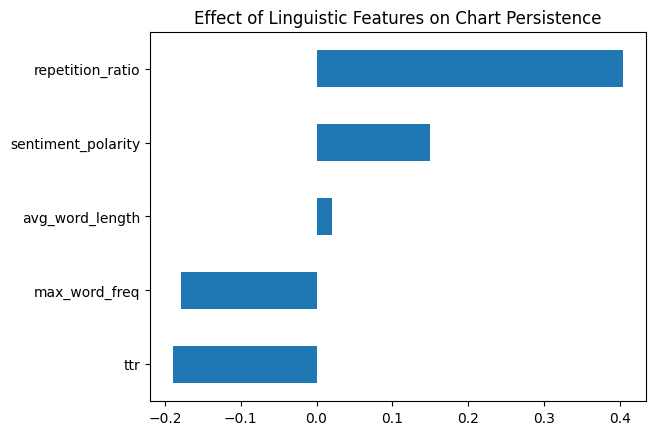

In [28]:
coef[linguistic_cols].sort_values().plot(kind="barh")
plt.title("Effect of Linguistic Features on Chart Persistence")
plt.show()

### TF-IDF Interpretation

In [29]:
coef_words = coef[X_tfidf_train_selected.columns]

# Remove repeated bigrams (e.g., "yeah yeah")
coef_words = coef_words[~coef_words.index.str.match(r'^(\w+)\s+\1$')]

top_positive = coef_words.sort_values(ascending=False).head(20)
top_negative = coef_words.sort_values().head(20)

### Plot top words

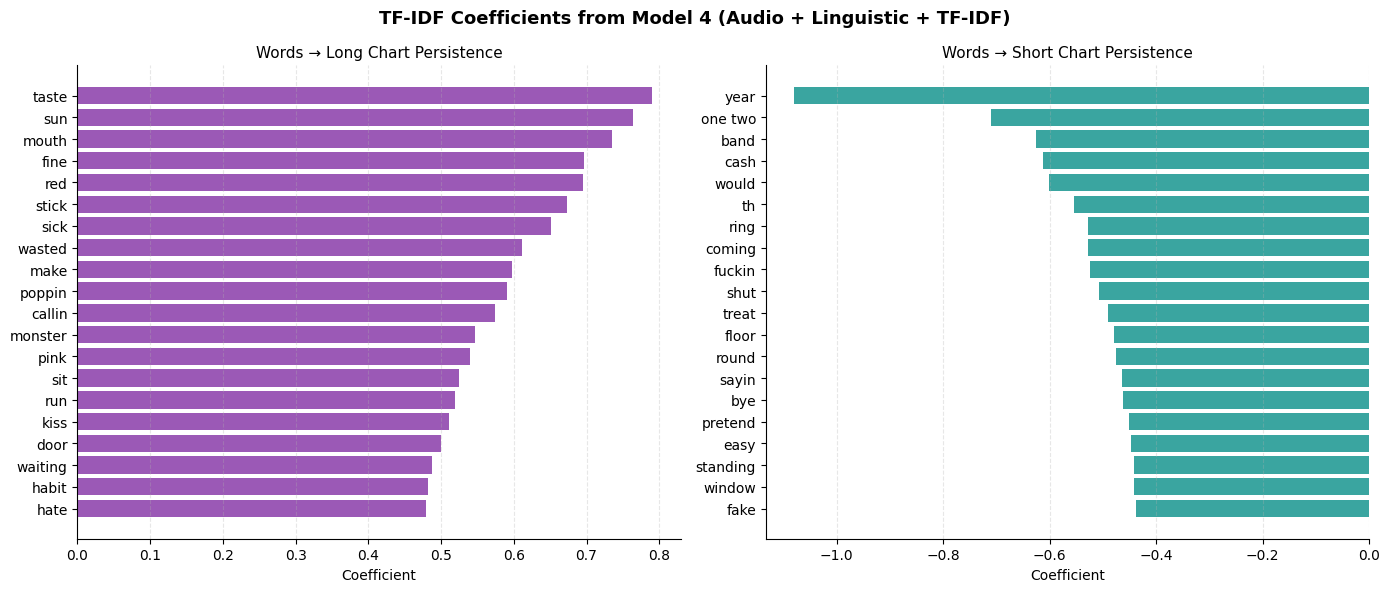

Saved → /Users/felipe/Documents/BSE/Term-2/Text-mining/Final_project/outputs/tfidf_top_words.png


In [30]:
# ── Top TF-IDF words: positive and negative in one two-panel figure ──────────
fig, (ax_pos, ax_neg) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("TF-IDF Coefficients from Model 4 (Audio + Linguistic + TF-IDF)",
             fontweight="bold", fontsize=13)

# Positive coefficients → associated with long chart runs
ax_pos.barh(
    top_positive.sort_values().index,
    top_positive.sort_values().values,
    color="#9B59B6"
)
ax_pos.set_title("Words → Long Chart Persistence", fontsize=11)
ax_pos.set_xlabel("Coefficient")
ax_pos.spines["top"].set_visible(False)
ax_pos.spines["right"].set_visible(False)
ax_pos.grid(axis="x", alpha=0.3, linestyle="--")

# Negative coefficients → associated with short chart runs
ax_neg.barh(
    top_negative.sort_values(ascending=False).index,
    top_negative.sort_values(ascending=False).values,
    color="#3AA5A0"
)
ax_neg.set_title("Words → Short Chart Persistence", fontsize=11)
ax_neg.set_xlabel("Coefficient")
ax_neg.spines["top"].set_visible(False)
ax_neg.spines["right"].set_visible(False)
ax_neg.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(OUTPUTS / "tfidf_top_words.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUTS / 'tfidf_top_words.png'}")
